In [1]:
%pylab inline

import warnings
warnings.filterwarnings("ignore")

from SCCAF import *
import scanpy as sc
import scVelo as svc

Populating the interactive namespace from numpy and matplotlib


In [4]:
ad = sc.read('data/FM_hippo_221150_wk.h5')


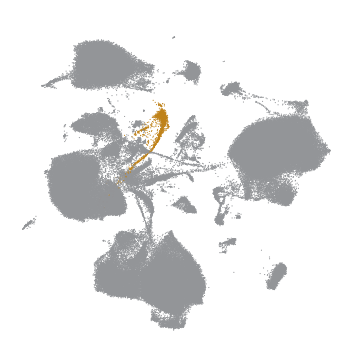

In [12]:
ad_sub= ad[~ad.obs['label_13'].isin(['doublets', 'doublets_1',
       'doublets_Astro_OPC', 'doublets_MG_OPC']),:]
matplotlib.rcParams.update({'font.size': 10})
fig = plt.figure(constrained_layout=True,figsize=(5,5))
#sns.despine()

gs = GridSpec(1, 1, figure=fig)
#ax1 = fig.add_subplot(gs[0, 0:])
ax2 = fig.add_subplot(gs[0, 0])
#ax1.annotate('a', (-1,1.05), size=5, xycoords=ax1.get_xaxis_transform(), weight='bold')
#ax2.annotate('b', (-42,1.03), size=15, xycoords=ax2.get_xaxis_transform(), weight='bold')
#ax6.annotate('c', (0,1.01), size=5, xycoords=ax6.get_xaxis_transform(), weight='bold')

#ax1.imshow(fig1a)
#ax1.set_axis_off()

ax2 = sc.pl.umap(ad_sub, color=['show_NB'],ax=ax2,legend_loc = None,\
           legend_fontsize=10,title=' ', show=False, size=5, frameon = False)

#ax2.spines['bottom'].set_color('#000000')
#ax2.spines['left'].set_color('#000000') 
#ax2.spines['top'].set_color('#FFFFFF')
#ax2.spines['right'].set_color('#FFFFFF')
#ax2.set_facecolor('white')

#ax2.xaxis.label.set_size(12)
#ax2.yaxis.label.set_size(12)


In [9]:
ad_NB = ad[ad.obs['label9']=='Neuroblast',:]
ad_NB

View of AnnData object with n_obs × n_vars = 1906 × 19888 
    obs: 'RNA_type', 'age', 'batch', 'batch_orig', 'cell_number', 'date', 'doublet_rate', 'sample', 'scrub_scores', 'scurb_doublets', 'sex', 'suffix', 'percent_mito', 'n_counts', 'n_genes', 'tenX_version', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'cell', 'Hochgerner1', 'Hochgerner2', 'doublet_score_zh', 'louvain', 'louvain_res2', 'label_1', 'label_2', 'class_show', 'Class', 'MonkeyID', 'label_wk', 'cell6', 'label7', 'label8', 'cell8', 'label9', 'label10', 'show_NB'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Hochgerner1_colors', 'Hochgerner2_colors', 'MonkeyID_colors', 'batch_colors', 'cell6_colors', 'cell8_colors', 'cell_colors', 'class_show_colors', 'hvg', 'label10_colors', 'label7_colors', 'label8_colors', 'label9_colors', 'label_1_colo

In [7]:
ad_zc = sc.read('NB_reg1_v.h5')
ad_zc

AnnData object with n_obs × n_vars = 1904 × 2000 
    obs: 'RNA_type', 'age', 'batch', 'batch_orig', 'cell_number', 'date', 'doublet_rate', 'sample', 'scrub_scores', 'scurb_doublets', 'sex', 'suffix', 'percent_mito', 'n_counts', 'n_genes', 'tenX_version', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'cell', 'Hochgerner1', 'Hochgerner2', 'leiden', 'cell1', 'leiden_r1.5', 'cell2', 'cell3', 'cell4', 'cell5', 'cell6', 'cell7', 'cell8', 'y', 'initial_size_spliced', 'initial_size_unspliced', 'initial_size', 'velocity_self_transition', 'cluster', 'pp'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', '

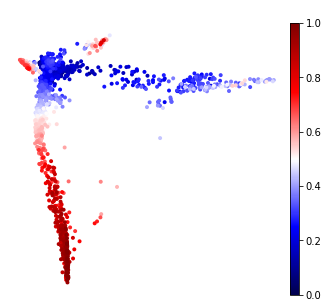

In [35]:
matplotlib.rcParams.update({'font.size': 10})
fig = plt.figure(figsize=(5.5,5))
#sns.despine()

gs = GridSpec(1, 1, figure=fig)
#ax1 = fig.add_subplot(gs[0, 0:])
ax2 = fig.add_subplot(gs[0, 0])
#ax1.annotate('a', (-1,1.05), size=5, xycoords=ax1.get_xaxis_transform(), weight='bold')
#ax2.annotate('b', (-42,1.03), size=15, xycoords=ax2.get_xaxis_transform(), weight='bold')
#ax6.annotate('c', (0,1.01), size=5, xycoords=ax6.get_xaxis_transform(), weight='bold')

#ax1.imshow(fig1a)
#ax1.set_axis_off()

ax2 = sc.pl.diffmap(ad_zc, color = 'latent_time', components = '4,1',title = ' ',
                    color_map='seismic',ax = ax2, frameon = False, show = False)

#ax2.spines['bottom'].set_color('#000000')
#ax2.spines['left'].set_color('#000000') 
#ax2.spines['top'].set_color('#FFFFFF')
#ax2.spines['right'].set_color('#FFFFFF')
#ax2.set_facecolor('white')

#ax2.xaxis.label.set_size(12)
#ax2.yaxis.label.set_size(12)


saving figure to file ./figures/scvelo_NB_scVelo_diff41.pdf


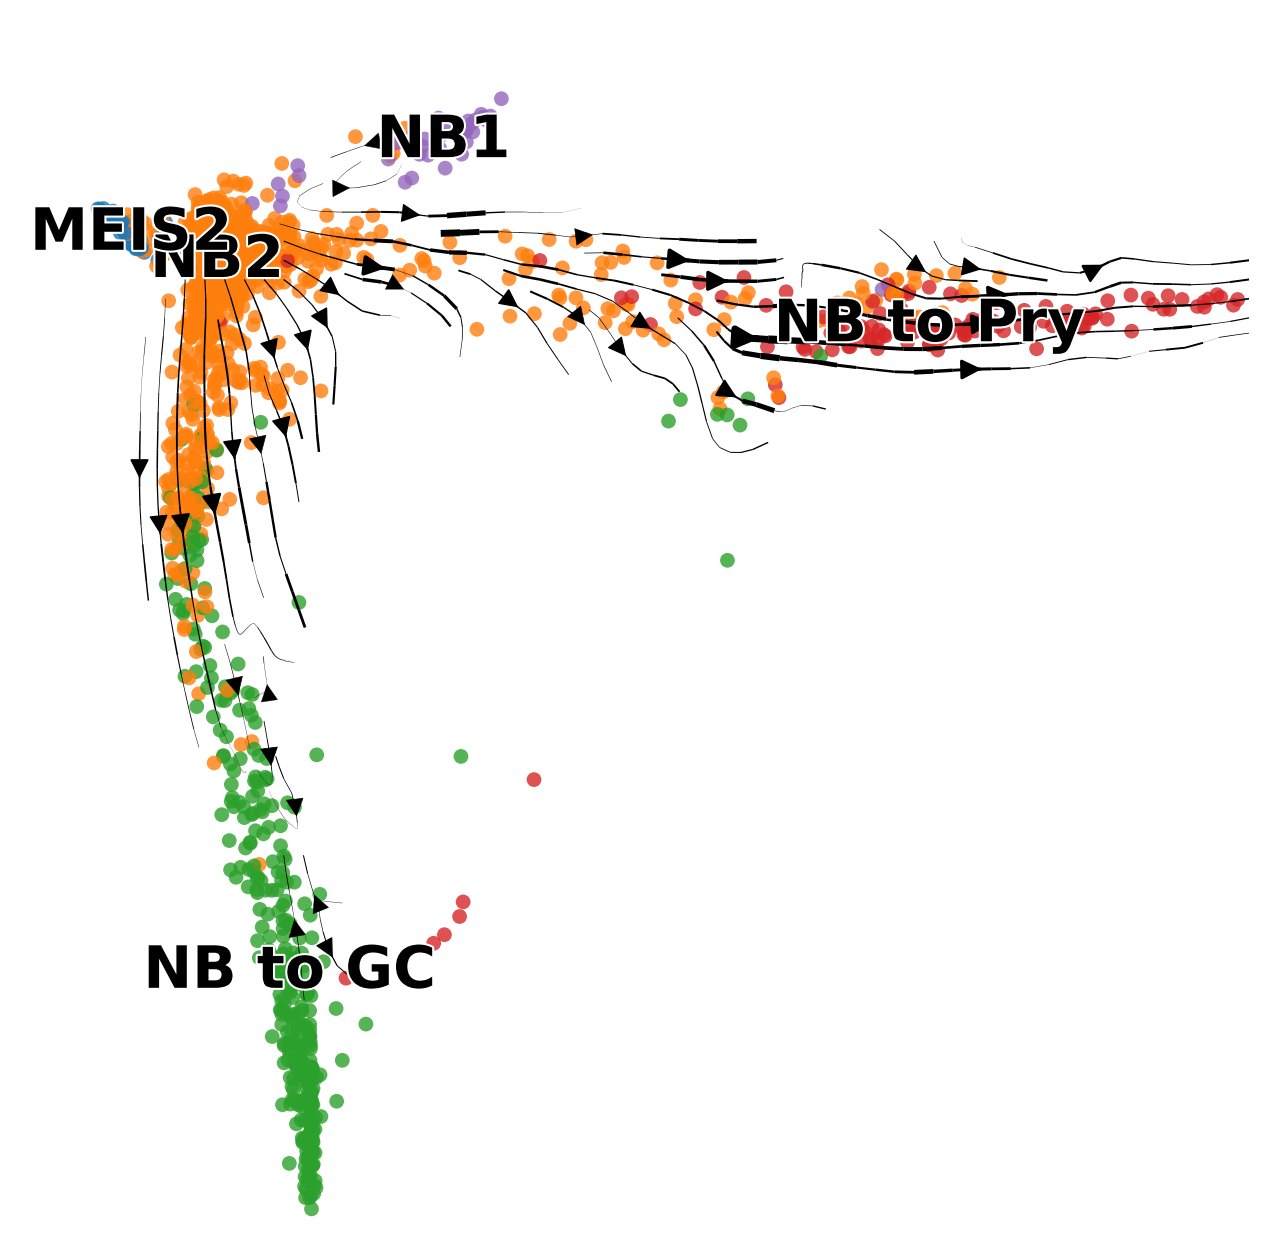

In [45]:
figsize(7,7)
scv.pl.velocity_embedding_stream(ad_zc, basis='diffmap', color = 'NB_split', components = '4,1',title = ' ',
                                 legend_fontsize = 14,alpha = 0.8,\
                                 figsize = (5,5),cutoff_perc = 20,s = 50,save = 'NB_scVelo_diff41.pdf',dpi = 300,)

saving figure to file ./figures/scvelo_heatmap_NB_velo_heat.png


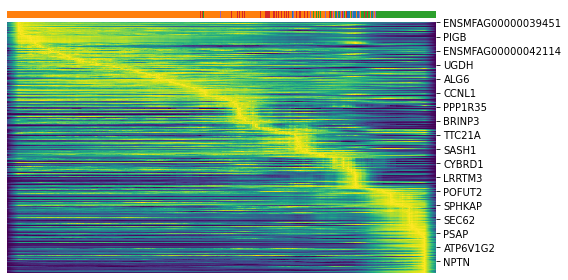

In [39]:
top_genes = ad_zc.var['fit_likelihood'].sort_values(ascending=False).index[:1000]
scv.pl.heatmap(ad_zc, var_names=top_genes, sortby='latent_time', col_color='NB_split', n_convolve=100, \
               figsize = (8,4), save = 'NB_velo_heat.png')

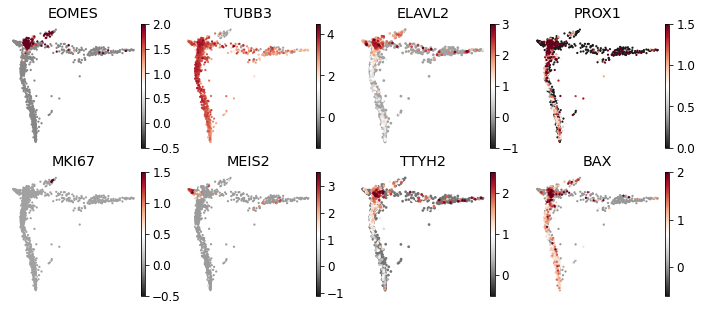

In [90]:
matplotlib.rcParams.update({'font.size': 12})
fig = plt.figure(figsize=(12,5))
#sns.despine()

gs = GridSpec(2, 4, figure=fig)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[0, 3])
ax5 = fig.add_subplot(gs[1, 0])
ax6 = fig.add_subplot(gs[1, 1])
ax7 = fig.add_subplot(gs[1, 2])
ax8 = fig.add_subplot(gs[1, 3])


#ax1.annotate('a', (-1,1.05), size=5, xycoords=ax1.get_xaxis_transform(), weight='bold')
#ax2.annotate('b', (-42,1.03), size=15, xycoords=ax2.get_xaxis_transform(), weight='bold')
#ax6.annotate('c', (0,1.01), size=5, xycoords=ax6.get_xaxis_transform(), weight='bold')

#ax1.imshow(fig1a)
#ax1.set_axis_off()
cm = 'RdGy_r'

ax1 = sc.pl.diffmap(ad_zc, color = 'EOMES', components = '4,1',title = 'EOMES',
                    color_map=cm,ax = ax1, frameon = False, show = False, vmin = -0.5,vmax = 2, s = 20)
ax2 = sc.pl.diffmap(ad_zc, color = 'TUBB3', components = '4,1',title = 'TUBB3',
                    color_map=cm,ax = ax2, frameon = False, show = False, vmin = -1.5,vmax = 4.5, s = 20)

ax3 = sc.pl.diffmap(ad_zc, color = 'ELAVL2', components = '4,1',title = 'ELAVL2', vmax = 3,
                    color_map=cm,ax = ax3, frameon = False, show = False, vmin = -1, s = 30)

ax4 = sc.pl.diffmap(ad_zc, color = 'PROX1', components = '4,1',title = 'PROX1',vmax = 1.5,
                    color_map=cm,ax = ax4, frameon = False, show = False,vmin = 0, s = 20)

ax5= sc.pl.diffmap(ad_zc, color = 'MKI67', components = '4,1',title = 'MKI67',vmax = 1.5,
                    color_map=cm,ax = ax5, frameon = False, show = False, vmin = -0.5, s = 20)

ax6 = sc.pl.diffmap(ad_zc, color = 'MEIS2', components = '4,1',title = 'MEIS2',vmax = 3.5,
                    color_map=cm,ax = ax6, frameon = False, show = False, vmin = -1.1, s = 20)

ax7 = sc.pl.diffmap(ad_zc, color = 'TTYH2', components = '4,1',title = 'TTYH2', vmax = 2.5,
                    color_map=cm,ax = ax7, frameon = False, show = False, vmin = -0.5, s = 30)

ax8 = sc.pl.diffmap(ad_zc, color = 'BAX', components = '4,1',title = 'BAX',vmax = 2,
                    color_map=cm,ax = ax8, frameon = False, show = False, vmin = -0.6, s = 20)


#ax2.spines['bottom'].set_color('#000000')
#ax2.spines['left'].set_color('#000000') 
#ax2.spines['top'].set_color('#FFFFFF')
#ax2.spines['right'].set_color('#FFFFFF')
#ax2.set_facecolor('white')

#ax2.xaxis.label.set_size(12)
#ax2.yaxis.label.set_size(12)


#fig.tight_layout(w_pad=0.3)
#plt.show()
plt.savefig("Figure/V5/Fig3_NB/Fig_NB_diffmap_8marker.pdf", dpi = 200)
plt.savefig("Figure/V5/Fig3_NB/Fig_NB_diffmap_8marker.png", dpi = 600)